
Processing scrambled embeddings...
Total keys in the .h5 file: 1068
First 5 keys: ['A0A0C5XL88 | Non-vertebrate', 'A0A0H3AIG7 | Vertebrate', 'A0A0H3CC30 | Non-vertebrate', 'A0A0H3KDT7 | Non-vertebrate', 'A0A0R4FQ94 | Non-vertebrate'] ...
Processing key: 'A0A0C5XL88 | Non-vertebrate', Embedding shape: (1024,)
Processing key: 'A0A0H3AIG7 | Vertebrate', Embedding shape: (1024,)
Processing key: 'A0A0H3CC30 | Non-vertebrate', Embedding shape: (1024,)
Processing key: 'A0A0H3KDT7 | Non-vertebrate', Embedding shape: (1024,)
Processing key: 'A0A0R4FQ94 | Non-vertebrate', Embedding shape: (1024,)
Processing key: 'A0A0R4J737 | Vertebrate', Embedding shape: (1024,)
Processing key: 'A0A0R4J7V3 | Vertebrate', Embedding shape: (1024,)
Processing key: 'A0A1V4PWS3 | Vertebrate', Embedding shape: (1024,)
Processing key: 'A0A2X3U5V2 | Vertebrate', Embedding shape: (1024,)
Processing key: 'A0A3T0PDD9 | Vertebrate', Embedding shape: (1024,)
Processing key: 'A0A3T1A1W4 | Vertebrate', Embedding shape: (1024

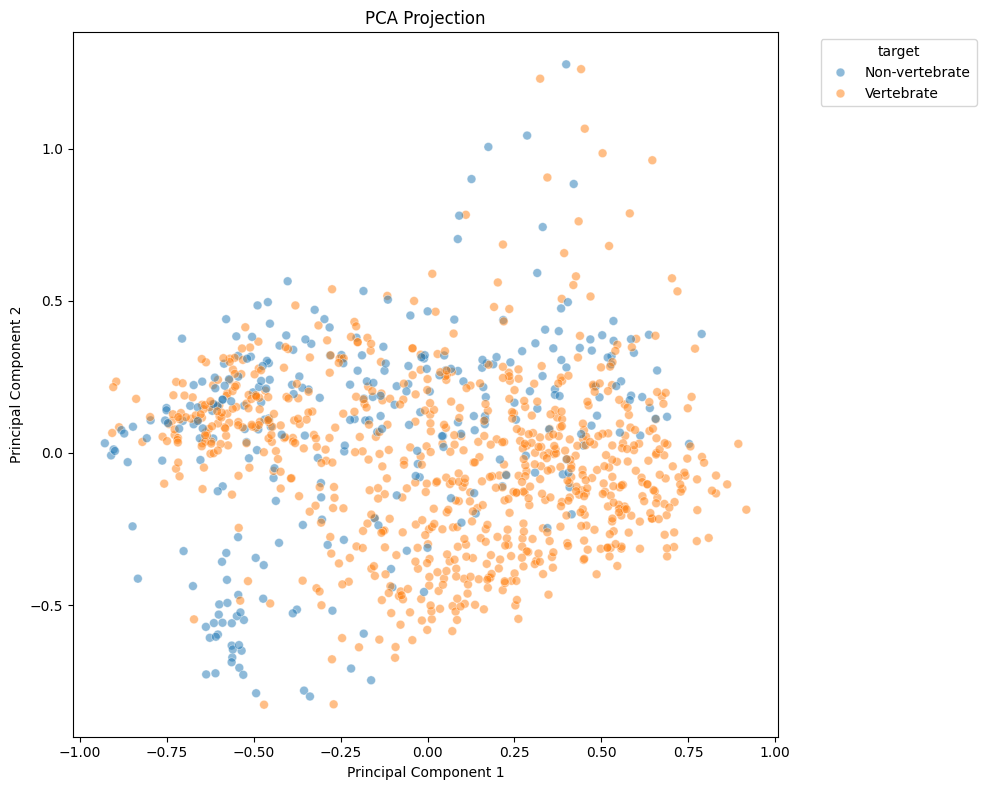

In [1]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
import os

# Function to load embeddings
def load_embeddings(embeddings_file_path):
    """
    Load embeddings from the .h5 file.
    Extracts only the ID part before the '|' symbol.
    """
    import h5py
    embeddings_list = []
    try:
        with h5py.File(embeddings_file_path, 'r') as f:
            keys = list(f.keys())
            print(f"Total keys in the .h5 file: {len(keys)}")
            print(f"First 5 keys: {keys[:5]} ...")
            for key in keys:
                emb_array = np.array(f[key])
                print(f"Processing key: '{key}', Embedding shape: {emb_array.shape}")

                # Ensure embeddings are 2D
                if emb_array.ndim == 1:
                    emb_array = emb_array.reshape(1, -1)
                elif emb_array.ndim == 2 and emb_array.shape[0] != 1:
                    print(f"Warning: Unexpected shape {emb_array.shape} for key '{key}'. Reshaping.")
                    emb_array = emb_array.reshape(1, -1)

                # Create DataFrame for embedding
                df = pd.DataFrame(
                    emb_array, 
                    columns=[f'feature_{i}' for i in range(emb_array.shape[1])]
                )
                df['ID'] = key.split('|')[0].strip().upper()
                embeddings_list.append(df)
        embeddings_df = pd.concat(embeddings_list, ignore_index=True)
        print(f"Total embeddings loaded: {embeddings_df.shape[0]}")
        print("Sample Embeddings:")
        print(embeddings_df.head())
        return embeddings_df
    except Exception as e:
        print(f"Error loading embeddings: {e}")
        return None

# Function to load labels
def load_labels(labels_file_path, label_column='target'):
    """
    Load labels from a CSV file.
    """
    try:
        labels_df = pd.read_csv(labels_file_path, delimiter=';')
        print(f"Labels loaded: {labels_df.shape[0]} records.")
        labels_df['ID'] = labels_df['ID'].str.replace('.', '_').str.strip().str.upper()
        print("Processed Labels IDs:")
        print(labels_df['ID'].head())

        if label_column not in labels_df.columns:
            print(f"Error: Label column '{label_column}' not found in labels file.")
            return None
        return labels_df[['ID', label_column]]
    except Exception as e:
        print(f"Error loading labels: {e}")
        return None

# Function to merge embeddings and labels
def merge_embeddings_labels(embeddings_df, labels_df):
    """
    Merge embeddings and labels on 'ID'.
    """
    merged_df = pd.merge(embeddings_df, labels_df, on='ID', how='inner')
    print(f"Merged data contains {merged_df.shape[0]} records.")
    if merged_df.empty:
        print("Warning: Merged DataFrame is empty.")
    else:
        print("Sample Merged Data:")
        print(merged_df[['ID', 'target']].head())
    return merged_df

# Function to perform PCA and save the plot
def plot_pca(embeddings_df, labels_df, label_column='target', output_dir=None):
    """
    Perform PCA on embeddings and save the plot.
    """
    merged_df = merge_embeddings_labels(embeddings_df, labels_df)
    if merged_df.empty:
        print("No data to plot.")
        return

    before_drop = merged_df.shape[0]
    merged_df = merged_df.dropna(subset=[label_column])
    print(f"Dropped {before_drop - merged_df.shape[0]} rows with missing '{label_column}'.")

    # Prepare features and labels
    X = merged_df.drop(['ID', label_column], axis=1).values
    y = merged_df[label_column].astype(str).values
    print(f"Features shape: {X.shape}")
    print(f"Labels shape: {y.shape}")

    # Perform PCA
    try:
        pca = PCA(n_components=2, random_state=42)
        X_pca = pca.fit_transform(X)
        print(f"PCA completed. Explained variance ratios: {pca.explained_variance_ratio_}")
    except Exception as e:
        print(f"Error during PCA: {e}")
        return

    # Create DataFrame for PCA results
    pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
    pca_df[label_column] = y

    # Automatically define legend order based on unique labels
    unique_labels = sorted(pca_df[label_column].unique())
    print(f"Unique labels in data: {unique_labels}")

    # Plot PCA
    plt.figure(figsize=(10, 8))
    try:
        sns.scatterplot(
            data=pca_df, 
            x='PC1', 
            y='PC2', 
            hue=label_column, 
            hue_order=unique_labels,
            palette='tab10',
            s=40,
            alpha=0.5  
        )
    except Exception as e:
        print(f"Error during plotting scatterplot: {e}")
        return

    plt.title('PCA Projection')
    plt.xlabel('Principal Component 1')
    plt.ylabel('Principal Component 2')
    plt.legend(title=label_column, bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()

    # Save the plot
    if output_dir:
        try:
            os.makedirs(output_dir, exist_ok=True)
            pca_plot_path = os.path.join(output_dir, 'pca_projection.png')
            plt.savefig(pca_plot_path, dpi=300)
            print(f"PCA plot saved to {pca_plot_path}")
        except Exception as e:
            print(f"Error saving plot: {e}")
    plt.show()
    plt.close()

# Paths to input files
embeddings_file_path = '/Users/didemdost/Desktop/output_original/per_residue_embeddings_training.h5'
labels_file_path = '/Users/didemdost/Desktop/folds/label.csv'
output_dir = '/Users/didemdost/Desktop/folds/pca'

# Run PCA
print("\nProcessing scrambled embeddings...")
embeddings_df = load_embeddings(embeddings_file_path)
labels_df = load_labels(labels_file_path, label_column='target')

if embeddings_df is not None and labels_df is not None:
    plot_pca(embeddings_df, labels_df, label_column='target', output_dir=output_dir)
else:
    print("Failed to load embeddings or labels.")
